In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
import sys
!{sys.executable} -m pip install arch

In [56]:
from arch.univariate import ARCHInMean, GARCH

In [ ]:
data_source = pd.read_excel("./usa_data.xlsx", index_col="Date").loc["1985-01-01":]

 
data_source.columns

Index(['Yeld_10Y', 'Price_10Y', 'Stock_Price', 'Dividend', 'E', 'CAPE',
       'T_Bill', 'CPI', 'Dividend_Yeld', 'Total_Stock_2', 'Total_Stock',
       'INDPRO'],
      dtype='object')

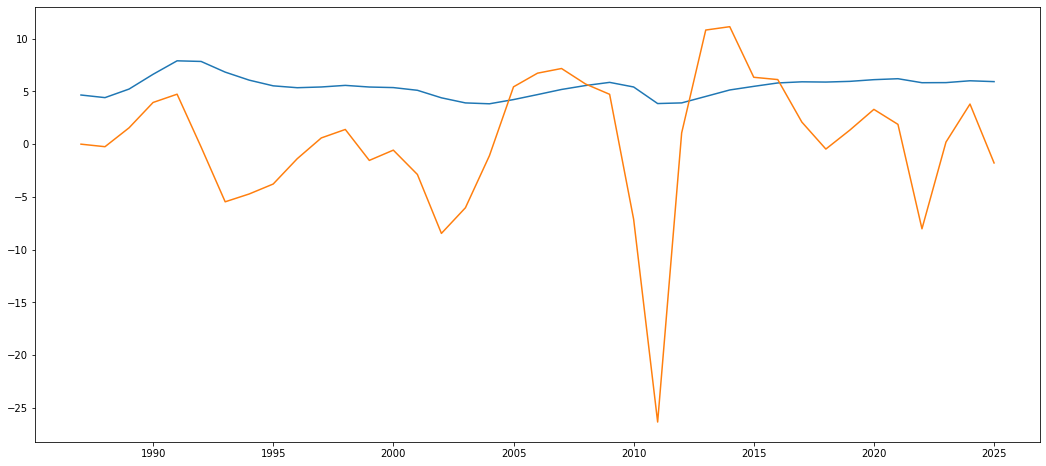

In [101]:
data = data_source.resample("Y").first().dropna()
div_growth = np.log1p(data["Dividend"].pct_change().dropna()) * 100
div_growth_mean = div_growth.mean()

expected_div_growth = div_growth.ewm(alpha=0.03).mean() 
div_shock = div_growth - expected_div_growth

fig = plt.figure(figsize=(18,8))
plt.plot(expected_div_growth, figure=fig)
plt.plot(div_shock, figure=fig)


In [ ]:
data["Yeld_10Y"] * 100

Date
1985-12-31    11.17
1986-12-31     9.08
1987-12-31     7.18
1988-12-31     8.26
1989-12-31     9.01
1990-12-31     8.43
1991-12-31     8.03
1992-12-31     7.31
1993-12-31     6.39
1994-12-31     5.70
1995-12-31     7.60
1996-12-31     5.60
1997-12-31     6.53
1998-12-31     5.53
1999-12-31     4.66
2000-12-31     6.68
2001-12-31     5.19
2002-12-31     5.07
2003-12-31     4.00
2004-12-31     4.16
2005-12-31     4.14
2006-12-31     4.53
2007-12-31     4.83
2008-12-31     3.67
2009-12-31     2.87
2010-12-31     3.63
2011-12-31     3.42
2012-12-31     1.83
2013-12-31     2.02
2014-12-31     2.67
2015-12-31     1.68
2016-12-31     1.94
2017-12-31     2.45
2018-12-31     2.72
2019-12-31     2.63
2020-12-31     1.51
2021-12-31     1.11
2022-12-31     1.79
2023-12-31     3.52
2024-12-31     3.99
Freq: A-DEC, Name: Yeld_10Y, dtype: float64

<AxesSubplot:xlabel='Date'>

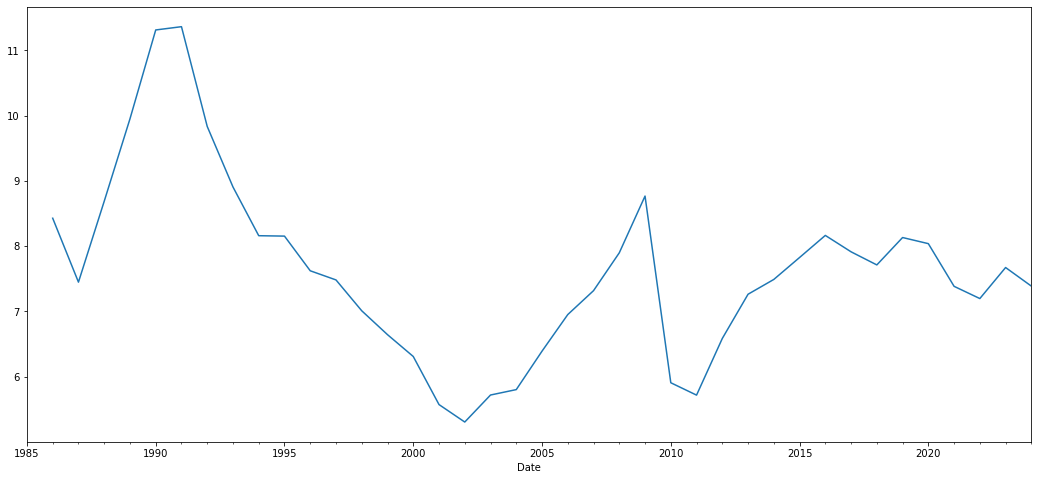

In [145]:
dy = data["Dividend_Yeld"] * 100
ret = dy + expected_div_growth #- data["Yeld_10Y"] * 100

fig = plt.figure(figsize=(18,8))
ret.plot(figure = fig)



In [157]:
ret

Date
1985-12-31          NaN
1986-12-31     8.427976
1987-12-31     7.448047
1988-12-31     8.687901
1989-12-31     9.951404
1990-12-31    11.314291
1991-12-31    11.364460
1992-12-31     9.834767
1993-12-31     8.906834
1994-12-31     8.159967
1995-12-31     8.153697
1996-12-31     7.622180
1997-12-31     7.481862
1998-12-31     7.008812
1999-12-31     6.642872
2000-12-31     6.308193
2001-12-31     5.571010
2002-12-31     5.303330
2003-12-31     5.717503
2004-12-31     5.800573
2005-12-31     6.390071
2006-12-31     6.951076
2007-12-31     7.317521
2008-12-31     7.897769
2009-12-31     8.767835
2010-12-31     5.905623
2011-12-31     5.715944
2012-12-31     6.584600
2013-12-31     7.262667
2014-12-31     7.489468
2015-12-31     7.825787
2016-12-31     8.164349
2017-12-31     7.912991
2018-12-31     7.712074
2019-12-31     8.131998
2020-12-31     8.038189
2021-12-31     7.383866
2022-12-31     7.196293
2023-12-31     7.672137
2024-12-31     7.387203
Freq: A-DEC, dtype: float64

In [156]:
gim = ARCHInMean(ret.loc["1986-01-01":], lags=1, volatility=GARCH())
res = gim.fit()
res.summary()

Iteration:      1,   Func. Count:      8,   Neg. LLF: 191702.45631174473
Iteration:      2,   Func. Count:     19,   Neg. LLF: 545.569648860311
Iteration:      3,   Func. Count:     27,   Neg. LLF: 1409.420891900561
Iteration:      4,   Func. Count:     35,   Neg. LLF: 142.07795276655258
Iteration:      5,   Func. Count:     43,   Neg. LLF: 1225.090829083109
Iteration:      6,   Func. Count:     51,   Neg. LLF: 16638.04076156565
Iteration:      7,   Func. Count:     59,   Neg. LLF: 96947.58921359721
Iteration:      8,   Func. Count:     67,   Neg. LLF: 485152.6839743892
Iteration:      9,   Func. Count:     75,   Neg. LLF: 40.82319850796424
Iteration:     10,   Func. Count:     83,   Neg. LLF: 33.941889980593466
Iteration:     11,   Func. Count:     90,   Neg. LLF: 33.09148249844522
Iteration:     12,   Func. Count:     97,   Neg. LLF: 33.608784132815074
Iteration:     13,   Func. Count:    105,   Neg. LLF: 33.191413408018796
Iteration:     14,   Func. Count:    113,   Neg. LLF: 32.988

<class 'statsmodels.iolib.summary.Summary'>
"""
                      ARCH-in-mean - GARCH Model Results                      
==============================================================================
Dep. Variable:                   None   R-squared:                       0.658
Mean Model:              ARCH-in-mean   Adj. R-squared:                  0.638
Vol Model:                      GARCH   Log-Likelihood:               -32.9870
Distribution:                  Normal   AIC:                           77.9741
Method:            Maximum Likelihood   BIC:                           87.7996
                                        No. Observations:                   38
Date:                Tue, Feb 17 2026   Df Residuals:                       35
Time:                        22:21:40   Df Model:                            3
                               Mean Model                               
========================================================================
                 coef    std err          t      P>|t|  95.0% Conf. Int.
------------------------------------------------------------------------
Const          2.8551      0.455      6.276  3.475e-10 [  1.963,  3.747]
None[1]        0.6288  5.982e-02     10.511  7.649e-26 [  0.512,  0.746]
kappa         -0.1213      0.215     -0.564      0.572 [ -0.543,  0.300]
                               Volatility Model                              
=============================================================================
                 coef    std err          t      P>|t|       95.0% Conf. Int.
-----------------------------------------------------------------------------
omega          0.0833  3.162e-02      2.634  8.440e-03    [2.131e-02,  0.145]
alpha[1]       1.0000      0.281      3.556  3.761e-04      [  0.449,  1.551]
beta[1]    7.8521e-12  3.972e-02  1.977e-10      1.000 [-7.785e-02,7.785e-02]
=============================================================================

Covariance estimator: robust
"""

In [158]:
scenarios = gim.simulate(res.params, 120)
scenarios

,data,volatility,errors
0,7.502999,0.636299,-0.275216
1,7.911517,0.398770,0.387036
2,8.113441,0.482774,0.342283
3,7.873777,0.447695,-0.028605
4,8.004568,0.289986,0.233746
...,...,...,...
115,7.376842,0.414018,-0.055126
116,7.774235,0.293790,0.316341
117,7.011374,0.428188,-0.680086
118,7.152615,0.738776,-0.021481


In [159]:
np.std(scenarios.data)

0.7647405970337033

<AxesSubplot:>

<Figure size 1296x576 with 0 Axes>

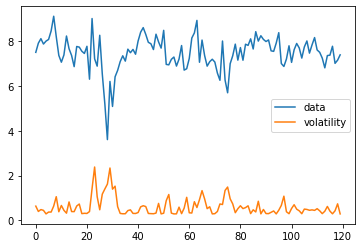

In [160]:
fig2 = plt.figure(figsize=(18,8))
scenarios[["data", "volatility"]].plot()